In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('/content/Telco_Customer_Churn.csv')

# --- DATA CLEANING ---

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



*   Checked for blank strings in all object columns.
*   Replaced the found blank strings with NaN values.
*   Dropped the rows with NaN values instead of imputing as there were only 11 such rows.
*   Fixed the data type of the TotalCharges feature, i.e, converted it from object type to float.


In [11]:
obj_cols = df.select_dtypes(include="object").columns

for col in obj_cols:
    blanks = (df[col].str.strip() == "").sum()
    if blanks > 0:
        print(col, blanks)

TotalCharges 11


In [12]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)

In [13]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,<NA>
753,0,20.25,<NA>
936,0,80.85,<NA>
1082,0,25.75,<NA>
1340,0,56.05,<NA>
3331,0,19.85,<NA>
3826,0,25.35,<NA>
4380,0,20.00,<NA>
5218,0,19.70,<NA>
6670,0,73.35,<NA>


In [15]:
df[df["tenure"] == 0]["TotalCharges"].isna().sum()

np.int64(11)

In [16]:
df = df.dropna(subset=["TotalCharges"])

In [17]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [18]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
df.duplicated().sum()

np.int64(0)

Saved customerID for reference and dropped it from the dataframe as it is not required for eda, segmentation or churn modeling.

In [20]:
customer_ids = df["customerID"]
df = df.drop(columns=["customerID"])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [22]:
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].unique())

gender
['Female' 'Male']
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
PhoneService
['No' 'Yes']
MultipleLines
['No phone service' 'No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['No' 'Yes' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn
['No' 'Yes']


# --- EDA ---

### Target Variable Distribution (Churn)

In [23]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


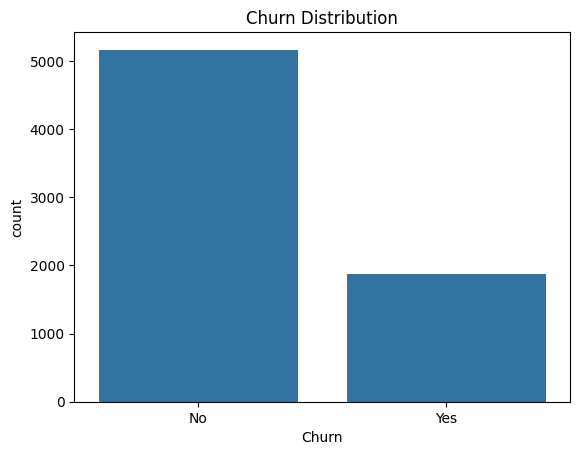

In [24]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [25]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


*   25% customers churn within the first 9 months.
*   The first year has the highest churn risk.
*   Customers are distributed across low, medium, and high pricing plans, making MonthlyCharges a strong candidate for price-based segmentation.
*   Fewer high value customers, but they contribute disproportionately to the revenue.





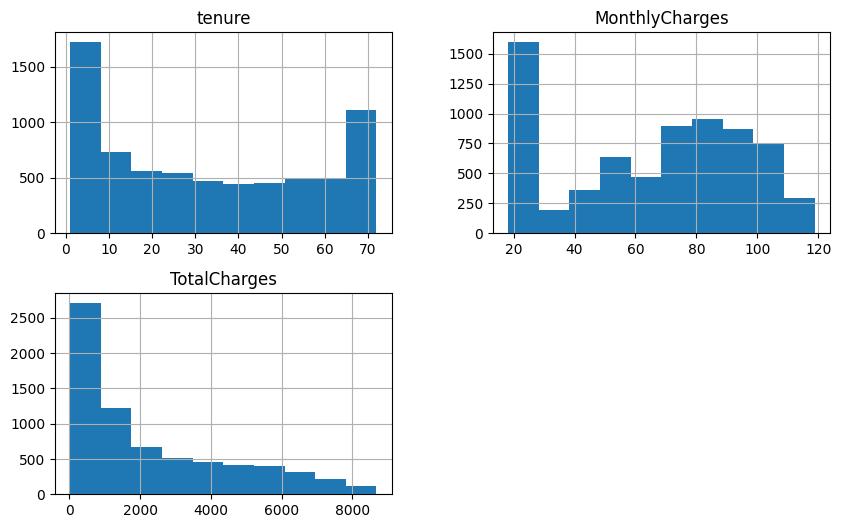

In [26]:
df[num_cols].hist(figsize=(10,6))
plt.show()

*   Majority of customers are within the first 2–3 years of tenure.
*   Monthly charges vary widely, enabling pricing-based segmentation.
*   Revenue contribution is highly skewed toward long-term customers.

### Churn vs Tenure and Monthly charges

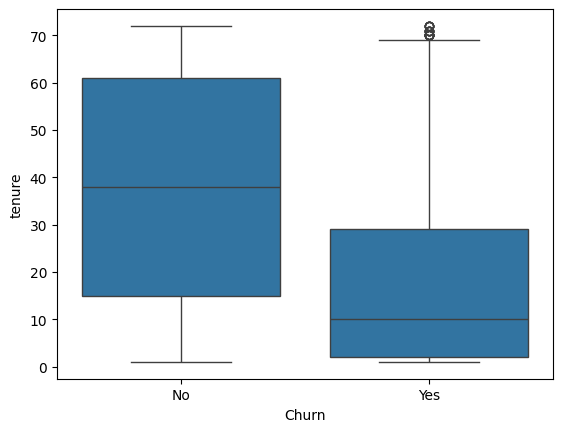

In [27]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

*   Low tenure customers churn more.



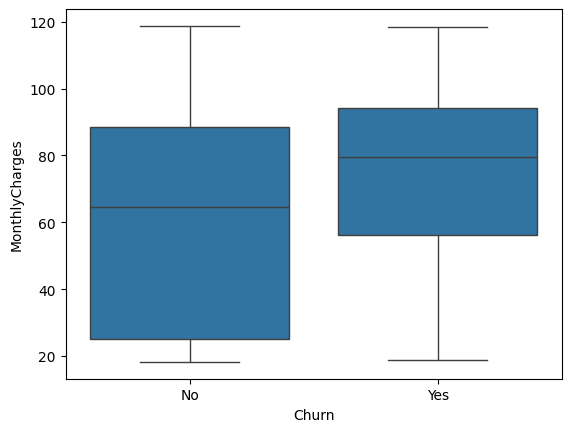

In [28]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

*   High-paying customers are more likely to churn

### Categorical features vs Churn

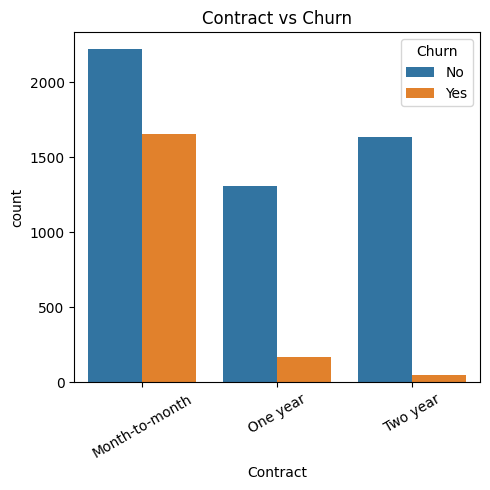

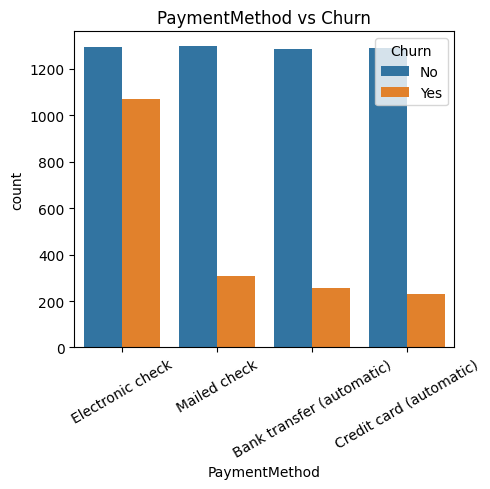

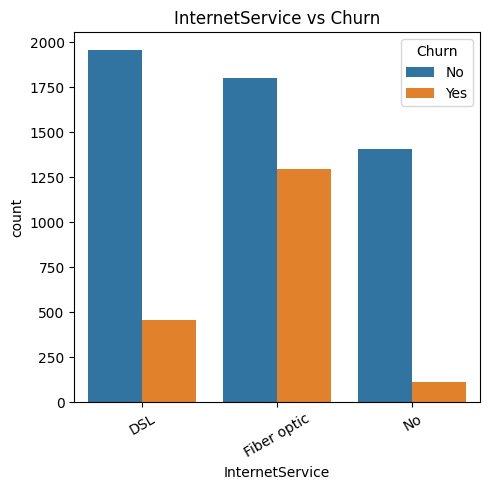

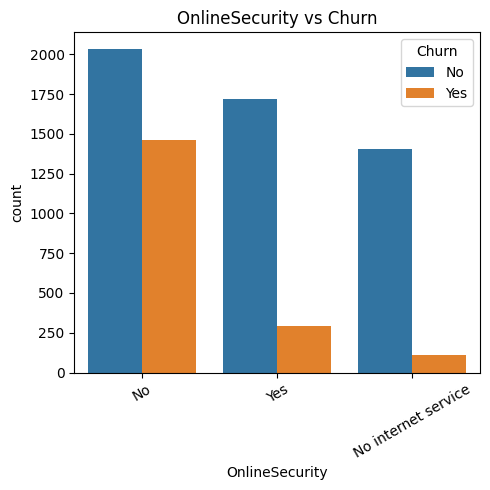

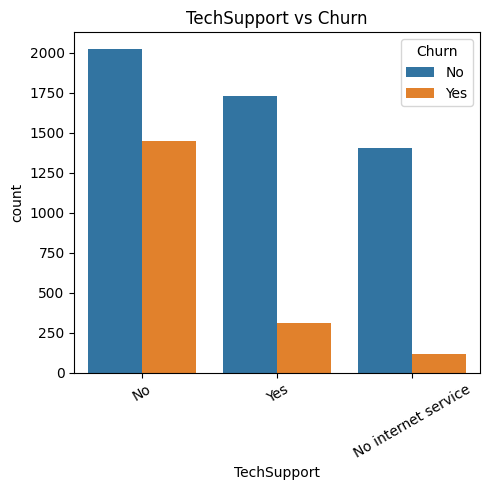

In [29]:
cat_cols = [
    "Contract", "PaymentMethod",
    "InternetService", "OnlineSecurity",
    "TechSupport"
]

for col in cat_cols:
    plt.figure(figsize=(5, 5))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

*   Month-to-month contracts show high churn.
*   No OnlineSecurity / TechSupport show high churn.
*   Fiber optic shows higher churn than DSL.
*   Customers using electronic check exhibit higher churn, likely due to lower commitment, manual payment friction, and association with month-to-month contracts.

### Correlation heatmap

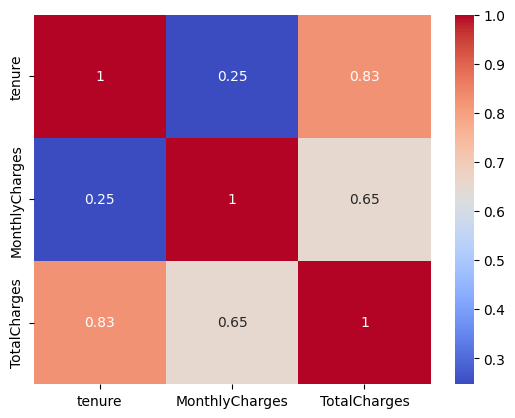

In [30]:
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

The correlation heatmap was used to identify linear dependencies among numerical features. As expected, tenure and total charges showed a strong correlation due to their mathematical relationship, while monthly charges showed moderate correlation with total charges. No strong multicollinearity was observed beyond this expected dependency.

## EDA Key Findings

*   Customers with short tenure are more likely to churn.
*   Month-to-month contracts show the highest churn rates.
*   Higher monthly charges correlate with higher churn.
*   Lack of support services increases churn risk.

# Feature Engineering and Encoding

In [31]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
cat_cols = df.select_dtypes(include="object").columns.drop("Churn")

In [32]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [33]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"].map({"Yes": 1, "No": 0})

In [34]:
from sklearn.preprocessing import StandardScaler

scaler_seg = StandardScaler()
X_segmentation = scaler_seg.fit_transform(X)

In [35]:
X_churn = X.copy()
scaler_churn = StandardScaler()
X_churn[num_cols] = scaler_churn.fit_transform(X_churn[num_cols])

# Segmentation

## Goal : Group telecom customers into distinct segments based on usage, billing, and service characteristics to enable targeted retention and marketing strategies.

### Why K-Means?

### Scales well to large datasets

### Works well with standardized numerical data

### Produces interpretable, compact clusters

### Industry-standard for customer segmentation

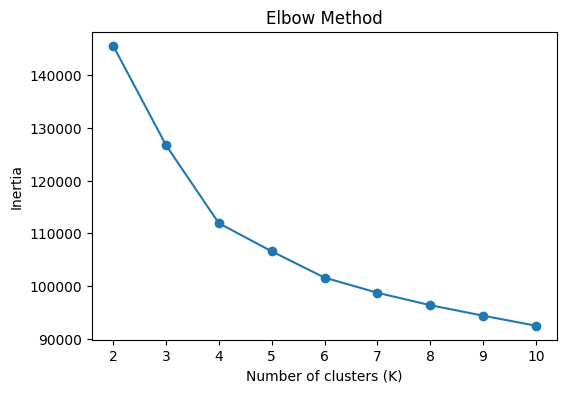

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_segmentation)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

*   The elbow method indicates diminishing returns beyond K=4
*   K=4 captures major customer structure without over-fragmentation
*   Higher K values reduce inertia only marginally

In [37]:
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_segmentation)
    sil_scores[k] = silhouette_score(X_segmentation, labels)

sil_scores

{2: np.float64(0.33510045574519265),
 3: np.float64(0.21938756320600342),
 4: np.float64(0.2390996613535271),
 5: np.float64(0.19250222616017082),
 6: np.float64(0.19429701352459597)}

Although K=2 achieved the highest silhouette score, it resulted in overly coarse segmentation.
K=4 was selected as it balances cluster compactness, interpretability, and business usefulness, consistent with the elbow method.

In [38]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Segment"] = kmeans.fit_predict(X_segmentation)

In [39]:
df["Segment"].value_counts(normalize=True)

,proportion
Segment,
2,0.389078
0,0.298066
1,0.216155
3,0.096701


*   Customer distribution across four segments is well-balanced
*   No segment is excessively small or dominant
*   Segmentation is suitable for targeted business strategies

In [40]:
segment_profile = df.groupby("Segment").agg({
    "tenure": "mean",
    "MonthlyCharges": "mean",
    "TotalCharges": "mean",
    "SeniorCitizen": "mean",
    "Churn": lambda x: (x == "Yes").mean()
})

segment_profile

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
Segment,,,,,
0,55.891221,91.899857,5159.003531,0.188931,0.147424
1,30.667763,21.076283,665.220329,0.034211,0.074342
2,15.563596,73.994170,1173.781963,0.215643,0.466740
3,31.830882,41.992500,1500.433750,0.152941,0.250000


*   Four distinct customer segments were identified using K-Means

*   High-value long-tenure customers exhibit low churn

*   New customers with high monthly charges show the highest churn risk

*   Segmentation enables targeted, cost-effective retention strategies

In [41]:
segment_names = {
    0: "High-Value Loyal",
    1: "Low-Usage Stable",
    2: "High-Risk High-Cost",
    3: "Mid-Tier Transitional"
}

df["Segment_Name"] = df["Segment"].map(segment_names)

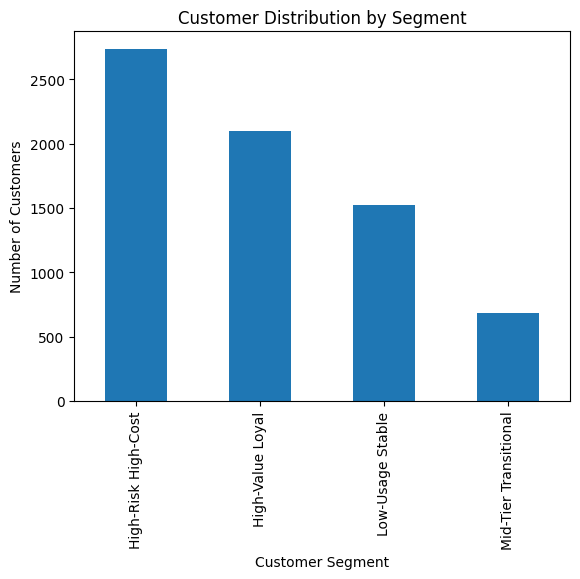

In [42]:
df["Segment_Name"].value_counts().plot(kind="bar")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Segment")
plt.show()

In [43]:
df["Churn_Num"] = df["Churn"].map({"Yes": 1, "No": 0})

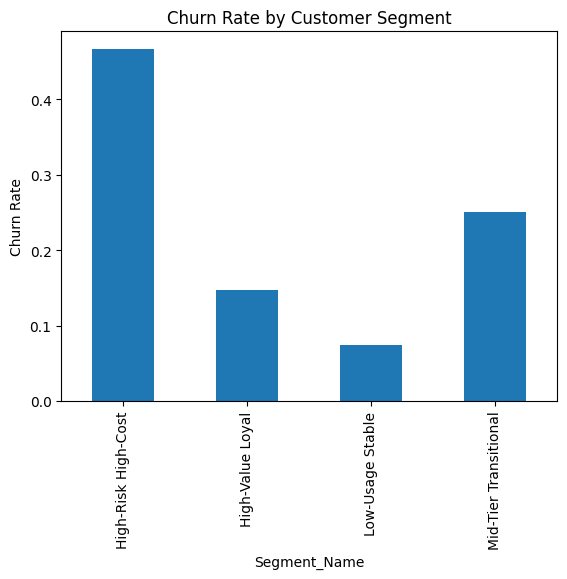

In [44]:
df.groupby("Segment_Name")["Churn_Num"].mean().plot(kind="bar")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Customer Segment")
plt.show()

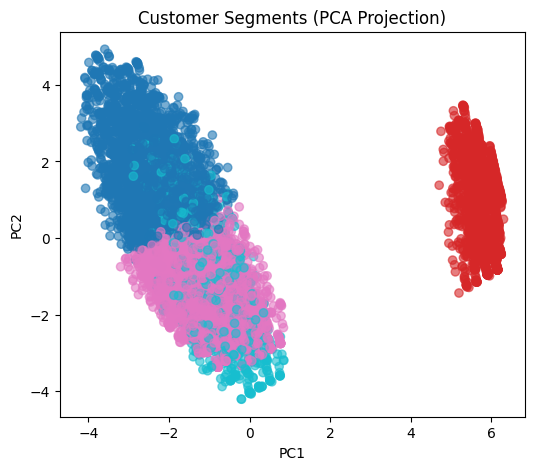

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_segmentation)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Segment"], cmap="tab10", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA Projection)")
plt.show()

Principal Component Analysis was applied to visualize customer segments in reduced dimensions. The first two components captured the dominant variance in customer behavior, primarily driven by tenure, billing amounts, and contract characteristics. The resulting PCA plot showed clear separation between customer segments, validating the effectiveness of the clustering approach.

In [46]:
pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PC1", "PC2"]
)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
PC1,-0.072091,-0.071183,-0.282509,-0.184941,0.003120,-0.025768,0.040656,0.029910,-0.029910,-0.111162,...,0.302377,-0.179026,0.302377,-0.180082,-0.002278,0.036641,-0.119469,-0.013650,-0.093990,0.131977
PC2,-0.059321,0.438529,0.083551,0.376584,-0.002242,0.261038,0.185434,0.116354,-0.116354,0.184522,...,0.117569,0.142388,0.117569,0.142780,0.095634,0.352863,-0.064301,0.183299,-0.213504,-0.055188


*   PC1 captures differences in service adoption and revenue contribution

*   PC2 captures customer stability, tenure, and contract commitment

*   Clear separation in PCA space confirms meaningful customer segments
*   PCA supports segmentation interpretability without using churn labels

# Segment profiling and interpretation

In [47]:
df["Segment"] = kmeans.labels_

In [48]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

segment_num_profile = (
    df.groupby("Segment_Name")[num_cols]
      .agg(["mean", "median"])
      .round(2)
)

segment_num_profile

tenure        MonthlyCharges        TotalCharges  \
                        mean median           mean median         mean   
Segment_Name                                                             
High-Risk High-Cost    15.56   11.0          73.99  75.22      1173.78   
High-Value Loyal       55.89   60.0          91.90  94.62      5159.00   
Low-Usage Stable       30.67   25.0          21.08  20.15       665.22   
Mid-Tier Transitional  31.83   29.0          41.99  40.55      1500.43   

                               SeniorCitizen         
                        median          mean median  
Segment_Name                                         
High-Risk High-Cost     834.18          0.22    0.0  
High-Value Loyal       5220.98          0.19    0.0  
Low-Usage Stable        523.67          0.03    0.0  
Mid-Tier Transitional  1153.80          0.15    0.0

In [49]:
df.groupby("Segment_Name")["Contract"].value_counts(normalize=True)

Segment_Name           Contract      
High-Risk High-Cost    Month-to-month    0.911915
                       One year          0.079313
                       Two year          0.008772
High-Value Loyal       Two year          0.414599
                       One year          0.356393
                       Month-to-month    0.229008
Low-Usage Stable       Two year          0.416447
                       Month-to-month    0.344737
                       One year          0.238816
Mid-Tier Transitional  Month-to-month    0.552941
                       Two year          0.233824
                       One year          0.213235
Name: proportion, dtype: float64

In [50]:
df.groupby("Segment_Name")["InternetService"].value_counts(normalize=True)

Segment_Name           InternetService
High-Risk High-Cost    Fiber optic        0.648026
                       DSL                0.351974
High-Value Loyal       Fiber optic        0.631202
                       DSL                0.368798
Low-Usage Stable       No                 1.000000
Mid-Tier Transitional  DSL                1.000000
Name: proportion, dtype: float64

In [51]:
support_cols = ["OnlineSecurity", "TechSupport"]

for col in support_cols:
    print(f"\n{col}")
    print(df.groupby("Segment_Name")[col].value_counts(normalize=True))


OnlineSecurity
Segment_Name           OnlineSecurity     
High-Risk High-Cost    No                     0.801535
                       Yes                    0.198465
High-Value Loyal       Yes                    0.568225
                       No                     0.431775
Low-Usage Stable       No internet service    1.000000
Mid-Tier Transitional  No                     0.586765
                       Yes                    0.413235
Name: proportion, dtype: float64

TechSupport
Segment_Name           TechSupport        
High-Risk High-Cost    No                     0.815789
                       Yes                    0.184211
High-Value Loyal       Yes                    0.595897
                       No                     0.404103
Low-Usage Stable       No internet service    1.000000
Mid-Tier Transitional  No                     0.577941
                       Yes                    0.422059
Name: proportion, dtype: float64


In [52]:
df.groupby("Segment_Name")["PaymentMethod"].value_counts(normalize=True)

Segment_Name           PaymentMethod            
High-Risk High-Cost    Electronic check             0.532164
                       Mailed check                 0.195906
                       Bank transfer (automatic)    0.146930
                       Credit card (automatic)      0.125000
High-Value Loyal       Credit card (automatic)      0.331584
                       Bank transfer (automatic)    0.317748
                       Electronic check             0.267653
                       Mailed check                 0.083015
Low-Usage Stable       Mailed check                 0.483553
                       Bank transfer (automatic)    0.218421
                       Credit card (automatic)      0.217763
                       Electronic check             0.080263
Mid-Tier Transitional  Electronic check             0.332353
                       Mailed check                 0.233824
                       Credit card (automatic)      0.225000
                       Bank transfer (automatic)    0.208824
Name: proportion, dtype: float64

In [53]:
segment_summary = df.groupby("Segment_Name").agg(
    Avg_Tenure=("tenure", "mean"),
    Avg_Monthly_Charges=("MonthlyCharges", "mean"),
    Avg_Total_Charges=("TotalCharges", "mean"),
    Churn_Rate=("Churn", lambda x: (x == "Yes").mean())
).round(2)

segment_summary

,Avg_Tenure,Avg_Monthly_Charges,Avg_Total_Charges,Churn_Rate
Segment_Name,,,,
High-Risk High-Cost,15.56,73.99,1173.78,0.47
High-Value Loyal,55.89,91.90,5159.00,0.15
Low-Usage Stable,30.67,21.08,665.22,0.07
Mid-Tier Transitional,31.83,41.99,1500.43,0.25


After clustering, segment profiling was performed using group-wise aggregation to understand average customer characteristics. This enabled interpretation of each segment in terms of tenure, spending behavior, and churn propensity

# Churn Analysis within Segments

Analyze churn patterns **within** each customer segment to understand how churn manifests differently across groups. This includes:
- Statistical significance testing (Chi-Square)
- Churn breakdown by contract type, payment method, and internet service within each segment
- Tenure distribution of churners vs non-churners per segment

### Chi-Square Test: Is churn distribution significantly different across segments?

In [54]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["Segment_Name"], df["Churn"])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Contingency Table:")
print(contingency)
print(f"\nChi-Square Statistic: {chi2:.2f}")
print(f"Degrees of Freedom : {dof}")
print(f"P-value            : {p_value:.2e}")
print(f"\nResult: {'Churn distribution is SIGNIFICANTLY different across segments (reject H0)' if p_value < 0.05 else 'No significant difference across segments (fail to reject H0)'}")

Contingency Table:
Churn                    No   Yes
Segment_Name                     
High-Risk High-Cost    1459  1277
High-Value Loyal       1787   309
Low-Usage Stable       1407   113
Mid-Tier Transitional   510   170

Chi-Square Statistic: 1003.00
Degrees of Freedom : 3
P-value            : 4.02e-217

Result: Churn distribution is SIGNIFICANTLY different across segments (reject H0)


### Churn Rate by Contract Type within Each Segment

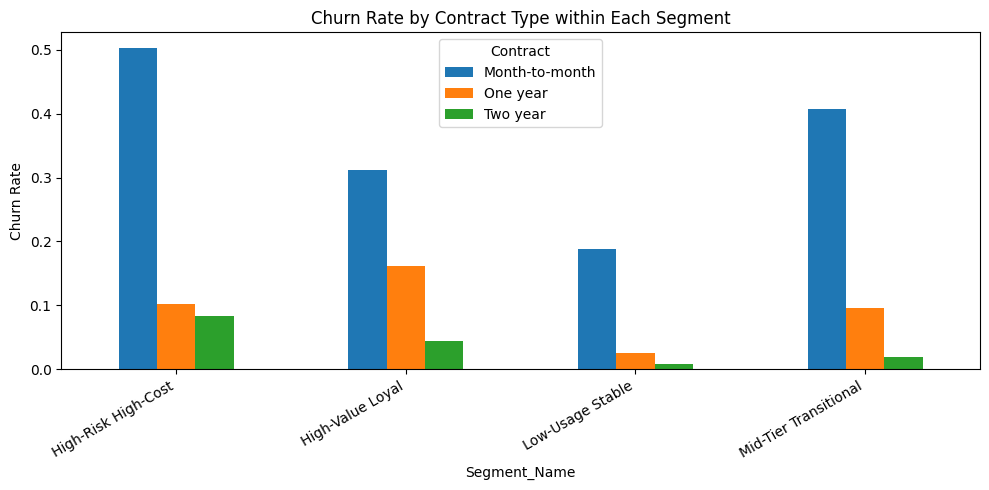

In [55]:
churn_contract_seg = df.groupby(["Segment_Name", "Contract"])["Churn_Num"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
churn_contract_seg.plot(kind="bar", ax=ax)
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Contract Type within Each Segment")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Contract")
plt.tight_layout()
plt.show()

### Churn Rate by Payment Method within Each Segment

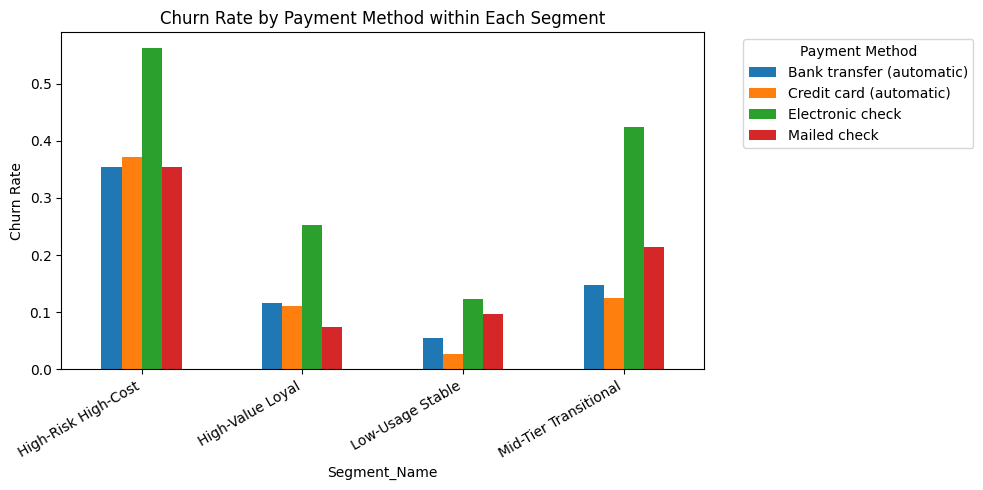

In [56]:
churn_payment_seg = df.groupby(["Segment_Name", "PaymentMethod"])["Churn_Num"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
churn_payment_seg.plot(kind="bar", ax=ax)
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Payment Method within Each Segment")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Payment Method", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Churn Rate by Internet Service within Each Segment

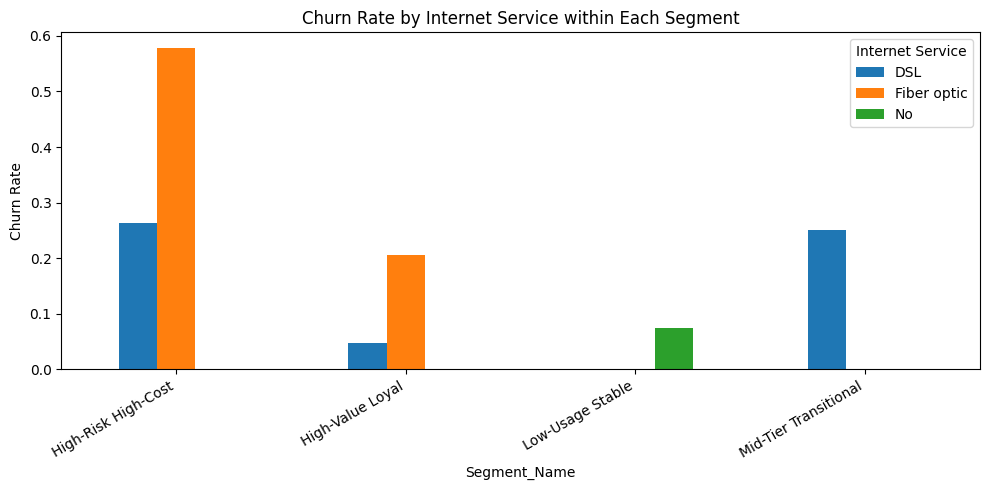

In [57]:
churn_internet_seg = df.groupby(["Segment_Name", "InternetService"])["Churn_Num"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
churn_internet_seg.plot(kind="bar", ax=ax)
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Internet Service within Each Segment")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Internet Service")
plt.tight_layout()
plt.show()

### Tenure Distribution of Churners vs Non-Churners per Segment

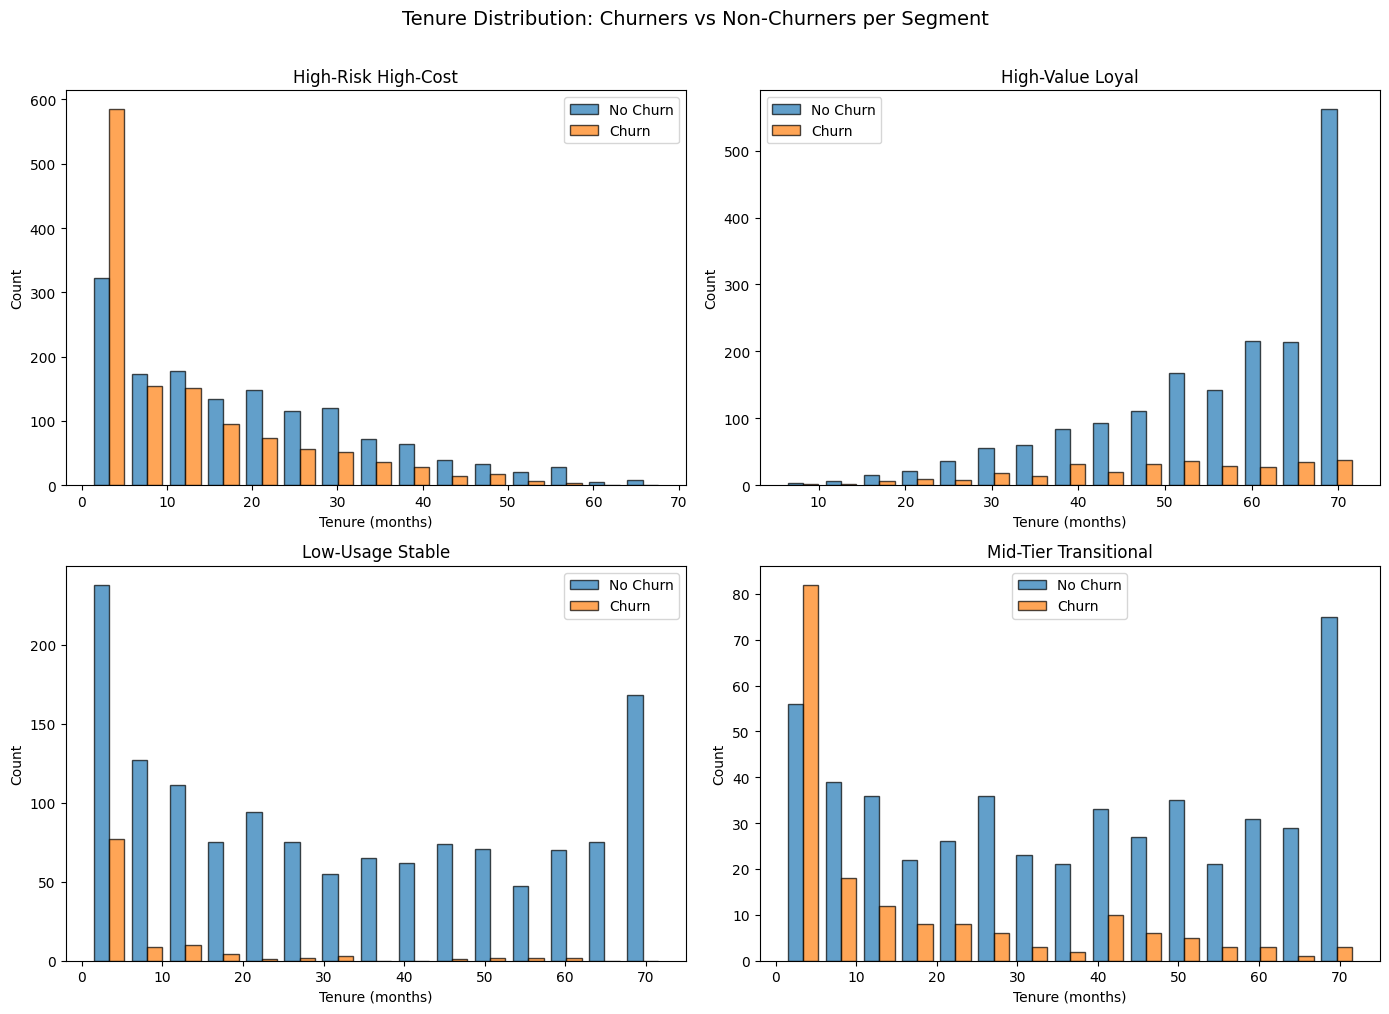

In [58]:
segments = df["Segment_Name"].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, seg in enumerate(sorted(segments)):
    seg_data = df[df["Segment_Name"] == seg]
    axes[i].hist(
        [seg_data[seg_data["Churn"] == "No"]["tenure"],
         seg_data[seg_data["Churn"] == "Yes"]["tenure"]],
        bins=15, label=["No Churn", "Churn"], alpha=0.7, edgecolor="black"
    )
    axes[i].set_title(f"{seg}")
    axes[i].set_xlabel("Tenure (months)")
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Tenure Distribution: Churners vs Non-Churners per Segment", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Segment-wise Churn Summary Table

In [59]:
churn_summary = df.groupby("Segment_Name").agg(
    Total_Customers=("Churn_Num", "count"),
    Churned=("Churn_Num", "sum"),
    Churn_Rate=("Churn_Num", "mean"),
    Avg_Tenure=("tenure", "mean"),
    Avg_MonthlyCharges=("MonthlyCharges", "mean"),
    Pct_Month_to_Month=("Contract", lambda x: (x == "Month-to-month").mean()),
    Pct_Electronic_Check=("PaymentMethod", lambda x: (x == "Electronic check").mean()),
    Pct_Fiber_Optic=("InternetService", lambda x: (x == "Fiber optic").mean()),
    Pct_No_OnlineSecurity=("OnlineSecurity", lambda x: (x == "No").mean()),
    Pct_No_TechSupport=("TechSupport", lambda x: (x == "No").mean()),
).round(3)

churn_summary["Churned"] = churn_summary["Churned"].astype(int)
churn_summary

,Total_Customers,Churned,Churn_Rate,Avg_Tenure,Avg_MonthlyCharges,Pct_Month_to_Month,Pct_Electronic_Check,Pct_Fiber_Optic,Pct_No_OnlineSecurity,Pct_No_TechSupport
Segment_Name,,,,,,,,,,
High-Risk High-Cost,2736,1277,0.467,15.564,73.994,0.912,0.532,0.648,0.802,0.816
High-Value Loyal,2096,309,0.147,55.891,91.900,0.229,0.268,0.631,0.432,0.404
Low-Usage Stable,1520,113,0.074,30.668,21.076,0.345,0.080,0.000,0.000,0.000
Mid-Tier Transitional,680,170,0.250,31.831,41.992,0.553,0.332,0.000,0.587,0.578


### Churn Analysis Findings

- **High-Risk High-Cost** segment has the highest churn rate, dominated by month-to-month contracts, fiber optic users, and electronic check payers with no security/support add-ons.
- **Mid-Tier Transitional** shows moderate churn, often from customers at a decision point — either committing long-term or leaving.
- **Low-Usage Stable** has moderate-to-low churn; these are typically basic-plan customers without internet-intensive services.
- **High-Value Loyal** exhibits the lowest churn; long tenure, annual contracts, and bundled services strongly correlate with retention.
- Within every segment, **month-to-month contracts** and **electronic check payments** consistently amplify churn risk.

# Key Churn Driver Identification

Identify the most influential features driving customer churn using two complementary approaches:
1. **Logistic Regression** — interpretable coefficients showing direction and magnitude of each feature's impact
2. **Random Forest** — non-linear feature importance capturing complex interactions

Both models are trained on the full encoded dataset to quantify the relative contribution of each variable to churn prediction.

### Logistic Regression — Feature Coefficients

In [60]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target
feature_cols = [
    c
    for c in df_encoded.columns
    if c not in ["Churn", "Segment", "Segment_Name", "Churn_Num"]
]
X_model = df_encoded[feature_cols].copy()
y_model = df_encoded["Churn"].map({"Yes": 1, "No": 0})

# 2. Scale the numerical features properly
num_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
scaler_lr = StandardScaler()

X_model_scaled = X_model.copy()
X_model_scaled[num_features] = scaler_lr.fit_transform(
    X_model_scaled[num_features]
)

# 3. Split the SCALED data into Train (70%), Dev (15%), and Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_model_scaled, y_model, test_size=0.30, random_state=42, stratify=y_model
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 4. Print confirmation of rows
print("--- Data Split Summary ---")
print(f"Train set (Features): {X_train.shape} | (Labels): {y_train.shape}")
print(f"Dev set   (Features): {X_dev.shape} | (Labels): {y_dev.shape}")
print(f"Test set  (Features): {X_test.shape} | (Labels): {y_test.shape}\n")


# 5. EXPORT EVERYTHING FOR NOTEBOOK 2 & FASTAPI
print("Saving artifacts...")

# Save the feature matrices as CSVs
X_train.to_csv("X_train.csv", index=False)
X_dev.to_csv("X_dev.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

# Save the target labels as CSVs
y_train.to_csv("y_train.csv", index=False)
y_dev.to_csv("y_dev.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# Save the Scaler object as a pickle (.pkl) file for FastAPI usage later
joblib.dump(scaler_lr, "scaler.pkl")

print("All files saved successfully and ready for Notebook 2!")

--- Data Split Summary ---
Train set (Features): (4922, 30) | (Labels): (4922,)
Dev set   (Features): (1055, 30) | (Labels): (1055,)
Test set  (Features): (1055, 30) | (Labels): (1055,)

Saving artifacts...
All files saved successfully and ready for Notebook 2!


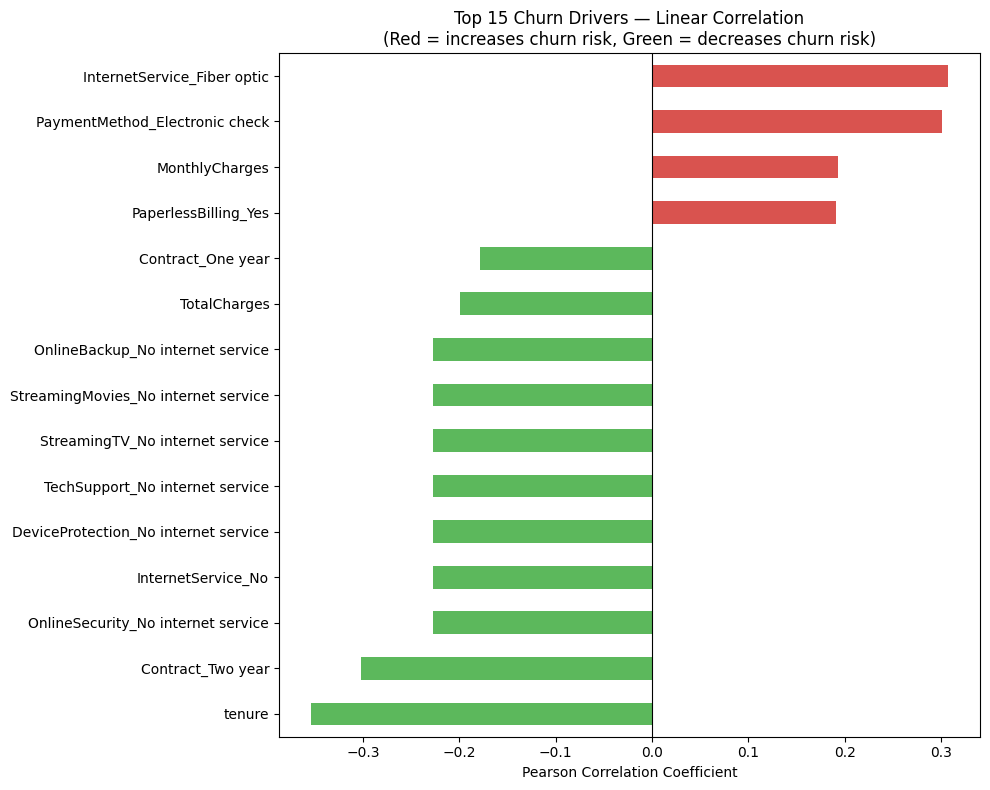

In [62]:
# Calculate correlation of all features with the Churn target variable
# (Since y_model is 1 for Yes and 0 for No)
correlations = X_model_scaled.corrwith(y_model).sort_values(key=abs, ascending=False)

# Grab the top 15 features affecting churn
top_15_corr = correlations.head(15).sort_values()

# Plot the drivers
fig, ax = plt.subplots(figsize=(10, 8))
top_15_corr.plot(
    kind="barh",
    ax=ax,
    color=["#d9534f" if v > 0 else "#5cb85c" for v in top_15_corr]
)

ax.set_xlabel("Pearson Correlation Coefficient")
ax.set_title("Top 15 Churn Drivers — Linear Correlation\n(Red = increases churn risk, Green = decreases churn risk)")
ax.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Random Forest — Feature Importance

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Random Forest — Test Set Performance:")
print(classification_report(y_test, rf.predict(X_test)))

Random Forest — Test Set Performance:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       775
           1       0.60      0.45      0.51       280

    accuracy                           0.77      1055
   macro avg       0.71      0.67      0.68      1055
weighted avg       0.76      0.77      0.76      1055



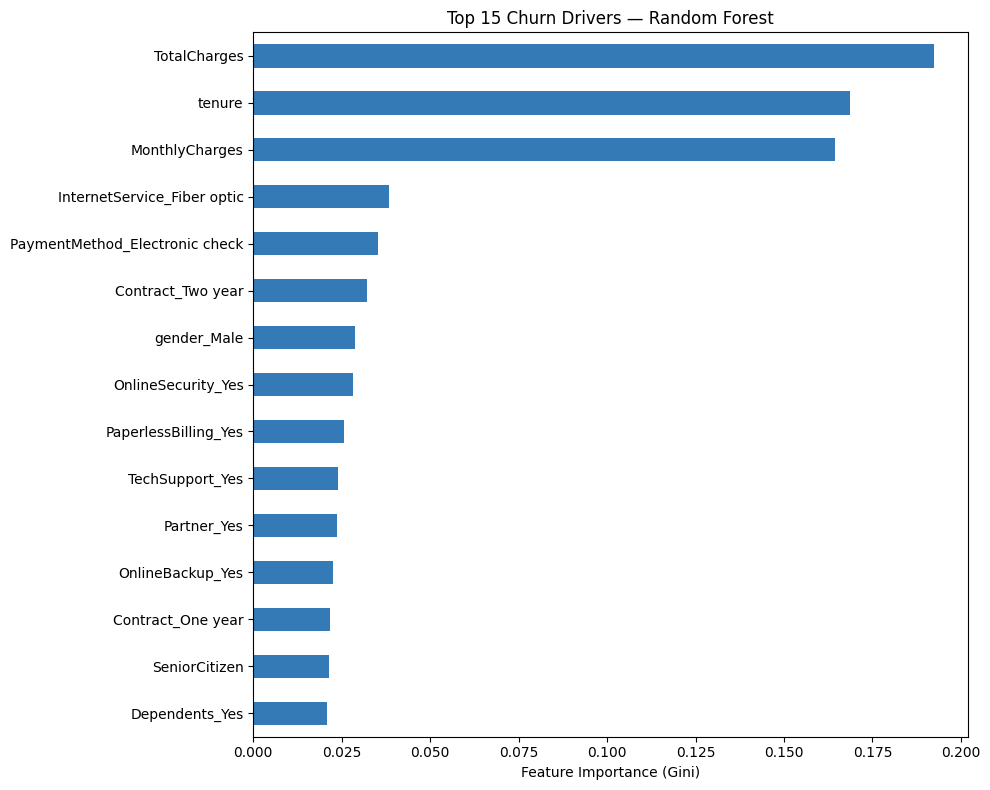

In [64]:
# Top churn drivers from Random Forest
rf_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
rf_importances.head(15).sort_values().plot(kind="barh", ax=ax, color="#337ab7")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Top 15 Churn Drivers — Random Forest")
plt.tight_layout()
plt.show()

### Per-Segment Churn Driver Analysis (Random Forest)

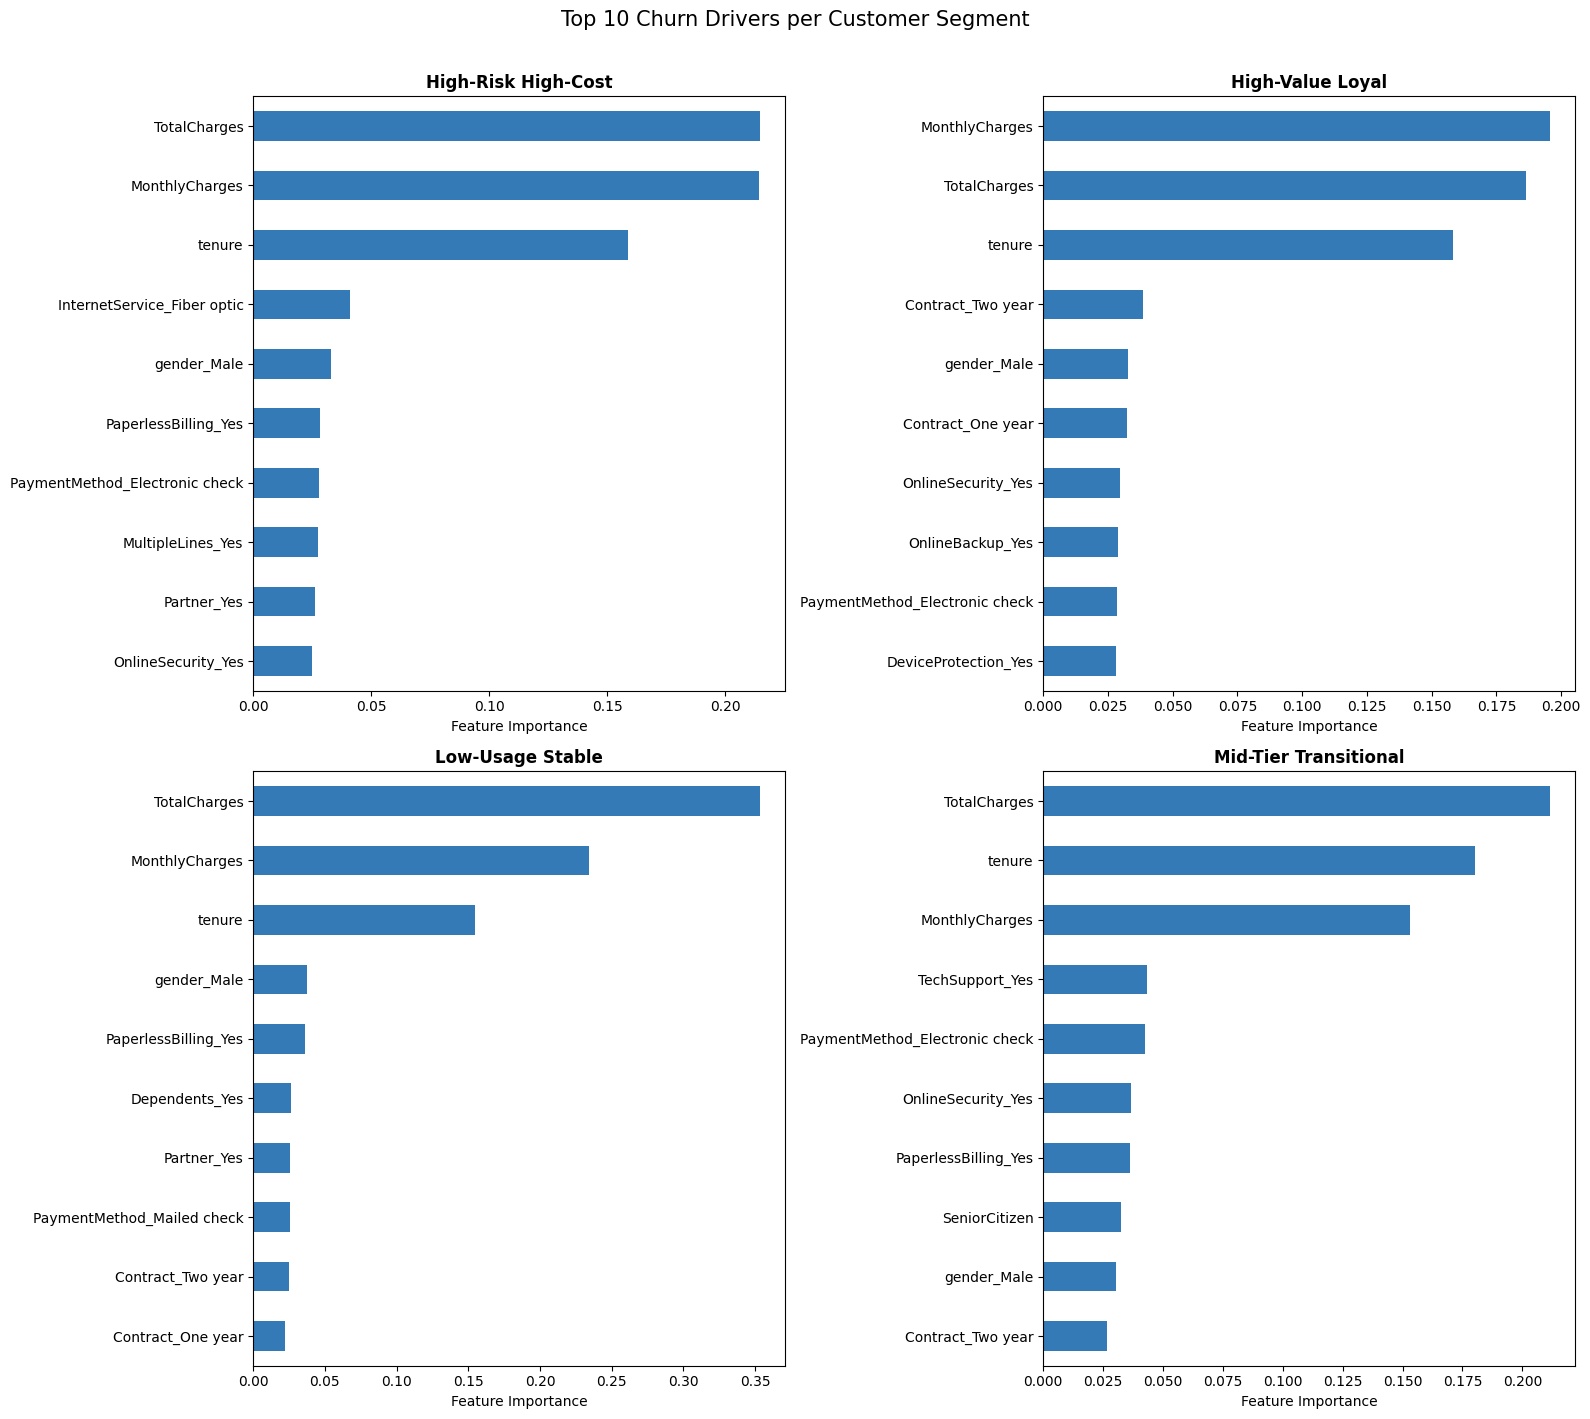

In [66]:
# Train a separate Random Forest per segment to identify segment-specific churn drivers
segment_names_list = sorted(df["Segment_Name"].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

segment_drivers = {}

for i, seg in enumerate(segment_names_list):
    seg_mask = df["Segment_Name"] == seg
    seg_encoded = df_encoded.loc[seg_mask]

    X_seg = seg_encoded[feature_cols]
    y_seg = seg_encoded["Churn"].map({"Yes": 1, "No": 0})

    if y_seg.nunique() < 2:
        axes[i].set_title(f"{seg}\n(Insufficient churn variance)")
        continue

    rf_seg = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
    rf_seg.fit(X_seg, y_seg)

    imp = pd.Series(rf_seg.feature_importances_, index=feature_cols).sort_values(ascending=False)
    segment_drivers[seg] = imp.head(10)

    imp.head(10).sort_values().plot(kind="barh", ax=axes[i], color="#337ab7")
    axes[i].set_title(f"{seg}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Feature Importance")

plt.suptitle("Top 10 Churn Drivers per Customer Segment", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Key Churn Driver Findings

**Overall Top Churn Drivers (consistent across both models):**
- **Tenure** — the single strongest predictor; short-tenure customers are most at risk
- **Contract type (Month-to-month)** — absence of commitment strongly drives churn
- **Monthly Charges** — higher bills increase dissatisfaction and churn likelihood
- **Internet Service (Fiber optic)** — fiber customers churn more, possibly due to pricing or service quality
- **Payment Method (Electronic check)** — manual, low-friction payment associated with less commitment
- **Lack of Online Security / Tech Support** — customers without bundled support services churn at significantly higher rates
- **Total Charges** — proxy for customer lifetime value; low total charges correlate with early exits

**Segment-Specific Insights:**
- In **High-Risk High-Cost**, monthly charges and fiber optic service dominate — these customers pay the most but feel they get inadequate value
- In **Mid-Tier Transitional**, contract type and tenure are critical — this group is at a decision point
- In **Low-Usage Stable**, internet service type and tenure dominate — basic users churn when expectations are unmet
- In **High-Value Loyal**, feature importance is more evenly distributed — no single acute risk factor, confirming their overall stability

# Retention Strategy Recommendations

Based on the churn analysis, key driver identification, and segment profiling, the following targeted retention strategies are recommended for each customer segment.

In [67]:
# Summary dashboard: segment profile with churn rate and revenue at risk
revenue_at_risk = df[df["Churn"] == "Yes"].groupby("Segment_Name")["MonthlyCharges"].sum()
total_revenue = df.groupby("Segment_Name")["MonthlyCharges"].sum()

strategy_table = churn_summary[["Total_Customers", "Churned", "Churn_Rate", "Avg_Tenure", "Avg_MonthlyCharges"]].copy()
strategy_table["Revenue_At_Risk"] = revenue_at_risk.round(0).astype(int)
strategy_table["Pct_Revenue_At_Risk"] = (revenue_at_risk / total_revenue * 100).round(1)
strategy_table = strategy_table.sort_values("Churn_Rate", ascending=False)

print("=" * 80)
print("RETENTION PRIORITY DASHBOARD")
print("=" * 80)
strategy_table

RETENTION PRIORITY DASHBOARD


,Total_Customers,Churned,Churn_Rate,Avg_Tenure,Avg_MonthlyCharges,Revenue_At_Risk,Pct_Revenue_At_Risk
Segment_Name,,,,,,,
High-Risk High-Cost,2736,1277,0.467,15.564,73.994,99862,49.3
Mid-Tier Transitional,680,170,0.250,31.831,41.992,6381,22.3
High-Value Loyal,2096,309,0.147,55.891,91.900,30586,15.9
Low-Usage Stable,1520,113,0.074,30.668,21.076,2302,7.2


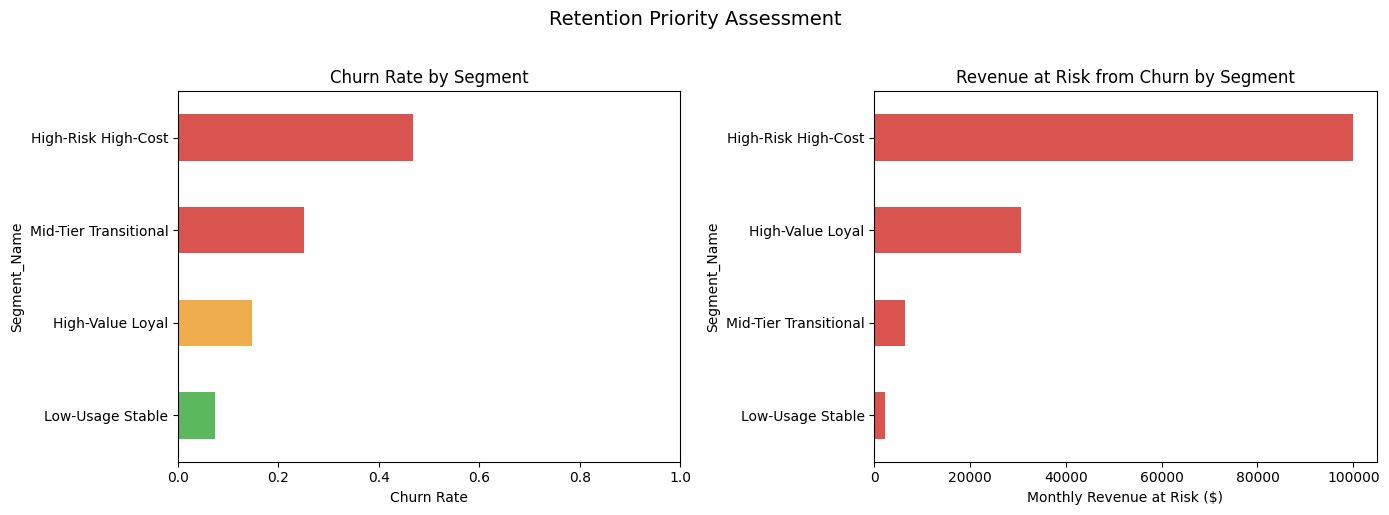

In [68]:
# Visual: Revenue at risk by segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn Rate
strategy_table["Churn_Rate"].sort_values(ascending=True).plot(
    kind="barh", ax=axes[0], color=["#5cb85c", "#f0ad4e", "#d9534f", "#d9534f"]
)
axes[0].set_xlabel("Churn Rate")
axes[0].set_title("Churn Rate by Segment")
axes[0].set_xlim(0, 1)

# Revenue at Risk
strategy_table["Revenue_At_Risk"].sort_values(ascending=True).plot(
    kind="barh", ax=axes[1], color="#d9534f"
)
axes[1].set_xlabel("Monthly Revenue at Risk ($)")
axes[1].set_title("Revenue at Risk from Churn by Segment")

plt.suptitle("Retention Priority Assessment", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Segment-Specific Retention Strategies

---

### 🔴 High-Risk High-Cost (PRIORITY: CRITICAL)
**Profile:** Short tenure, highest monthly charges, predominantly month-to-month contracts, fiber optic internet, electronic check payments, no security/support add-ons.

**Strategies:**
1. **Immediate contract migration incentives** — Offer 20–30% discount for switching from month-to-month to annual or two-year contracts within the first 3 months.
2. **Fiber optic value enhancement** — Bundle free Online Security and Tech Support for 6 months to increase perceived value of high-cost plans.
3. **Proactive outreach at tenure milestones** — Trigger personalized retention calls at months 1, 3, and 6 when churn risk peaks.
4. **Auto-pay migration campaign** — Incentivize switching from electronic check to automatic bank transfer or credit card with a one-time bill credit.
5. **Price-lock guarantee** — Guarantee no price increases for 12 months for new contract sign-ups.

---

### 🟠 Mid-Tier Transitional (PRIORITY: HIGH)
**Profile:** Moderate tenure and charges, mixed contract types, at a decision point between commitment and exit.

**Strategies:**
1. **Loyalty milestone rewards** — Offer tiered benefits at 6, 12, and 18-month tenure milestones (e.g., free premium feature for a month, bill credits).
2. **Personalized upgrade offers** — Use usage patterns to recommend relevant service add-ons (streaming, security) at a bundled discount.
3. **Contract renewal incentives** — For those approaching the end of annual contracts, proactively offer renewal discounts before the contract expires.
4. **Engagement campaigns** — Send monthly value reports showing how much they've utilized their services to reinforce perceived value.

---

### 🟡 Low-Usage Stable (PRIORITY: MODERATE)
**Profile:** Low monthly charges, basic service plans, relatively stable but at risk when service expectations aren't met.

**Strategies:**
1. **Service education campaigns** — Educate on available features they may not be using (e.g., online security, streaming) to increase engagement and stickiness.
2. **Gentle upsell path** — Offer free 1-month trials of add-on services to demonstrate value without financial risk.
3. **Simplified billing communication** — Ensure billing is clear and transparent; avoid unexpected charges that disproportionately affect cost-sensitive customers.
4. **Community building** — Include this segment in customer satisfaction surveys; their feedback can prevent silent churn.

---

### 🟢 High-Value Loyal (PRIORITY: MAINTAIN)
**Profile:** Longest tenure, highest total charges, annual/two-year contracts, bundled services, lowest churn.

**Strategies:**
1. **VIP recognition program** — Create an exclusive loyalty tier with perks (priority support, early access to new features, dedicated account manager).
2. **Referral incentives** — Leverage their satisfaction: offer bill credits for successful referrals of new customers.
3. **Preventive monitoring** — Even though churn is low, flag any sudden changes in usage patterns (e.g., reduced data consumption, support ticket spikes) as early warnings.
4. **Annual appreciation touchpoints** — Send personalized thank-you communications and anniversary offers to reinforce the relationship.

---

## Cross-Segment Recommendations

| Strategy | Expected Impact | Segments Impacted |
|---|---|---|
| Migrate month-to-month to annual contracts | High | High-Risk, Mid-Tier |
| Bundle security/support add-ons | High | High-Risk, Low-Usage |
| Auto-pay incentives (away from electronic check) | Medium | High-Risk, Mid-Tier |
| Proactive outreach in first 6 months | High | High-Risk, Mid-Tier |
| Loyalty reward milestones | Medium | Mid-Tier, Low-Usage |
| VIP program for long-tenure customers | Low (preventive) | High-Value Loyal |

---

## Conclusion

This project demonstrated a complete customer churn analytics pipeline — from data cleaning through segmentation to actionable strategy formulation. By combining **K-Means clustering** for customer segmentation with **Logistic Regression** and **Random Forest** for churn driver identification, we achieved both interpretability and predictive power.

The analysis reveals that **churn is not uniform** — it manifests differently across customer segments, requiring **tailored retention strategies** rather than one-size-fits-all approaches. The highest-impact interventions focus on **contract migration**, **service bundling**, and **proactive engagement during early tenure months**, which together address the root causes identified by both models.